In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# Define a function to compute analytical solution to the logistic
# equation at different growth rates and carrying capacities
def y(t, N0, r=0.5, K=10.):
    """Calculate the analytical solution to the logistic equation

    Args:
        t (numpy.ndarray): time
        N0 (numpy.float64): initial population (unit: # of animals)
        r (float): growth rate (unit 1/time)
        K (float): carrying capacity (unit: # of animals)

    Returns:
        numpy.ndarray: analytical solution to the logistic equation
    """
    
    N = K / (1. - ((N0-K)/N0) * np.exp(-r*t) )
    
    return N 

In [3]:
# Define variables (only vary the initial conditions)
t = np.linspace(0,10,101)              # 101 points in time spanning [0, 10]
N0 = 2.0           # array of 10 initial conditions 
r = 0.5                                # growth rate
arr_K = 5. * np.arange(1,5)                                # carrying capacity

In [ ]:
I picked N0 = 2.0 because that was the lower bound in the original code (arr_N0 = 2. * np.arange(1,11)).

In [4]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['mathtext.default'] = 'regular'
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 20

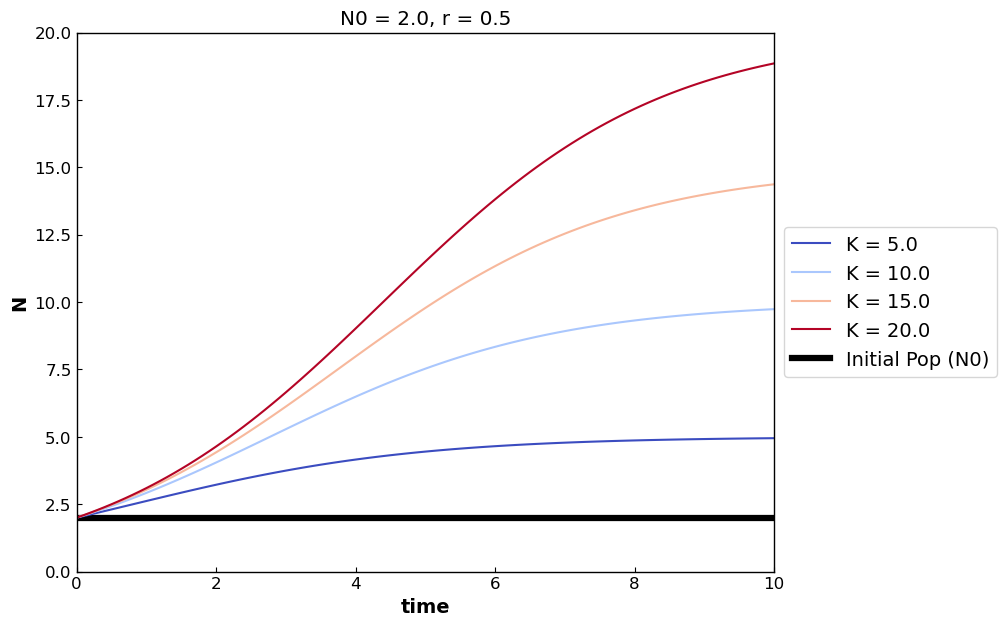

In [ ]:
# Plot solutions for different initial population choices
fig, ax = plt.subplots(1,1,figsize=(9,7))

# Create a color gradient for plotting all solutions
# Check out more colormaps: https://matplotlib.org/stable/tutorials/colors/colormaps.html
n = len(arr_K) # number of solutions
colors = plt.cm.coolwarm(np.linspace(0.,1.,n))

# Loop over initial conditions and plot each solution
for idx, k in enumerate(arr_K):
    ax.plot(t, y(t, N0=N0, r=r, K=k), linewidth=1.5, color=colors[idx], label=f"K = {k}")

# Plot the carrying capacity as a reference
# zorder=0 sets the line behind the other lines
ax.plot([t.min(), t.max()], [N0, N0], color='k', linewidth=4.5, label='Initial Pop (N0)', zorder=0)

# Set axes range
ax.set_xlim(0,10)
ax.set_ylim(0,20)

# Set axes labels and figure title
ax.set_xlabel('time')
ax.set_ylabel('N')
ax.set_title(f'N0 = {N0}, r = {r}') 
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()